# 03_How_The_Algorithm_Works.ipynb

---

# Step-by-Step Workflow

Elastic Net follows almost the same workflow as Linear Regression, but during training it **adds both L1 and L2 penalties** to the loss function.

Overall pipeline:

```text
Input Dataset
      │
      ▼
Train-Test Split
      │
      ▼
Feature Scaling (StandardScaler)
      │
      ▼
Initialize Coefficients
      │
      ▼
Predict Values
      │
      ▼
Calculate Loss
(MSE + L1 Penalty + L2 Penalty)
      │
      ▼
Compute Gradients
      │
      ▼
Update Coefficients
      │
      ▼
Repeat Until Convergence
      │
      ▼
Final Model
      │
      ▼
Prediction on New Data
```

---

## Step 1 — Collect the Dataset

Example:

| Area | Bedrooms | Price |
| ---- | -------- | ----- |
| 1000 | 2        | 40    |
| 1200 | 3        | 50    |
| 1500 | 3        | 60    |
| 1800 | 4        | 72    |

Features

```text
X =
[
Area,
Bedrooms
]
```

Target

```text
y = Price
```

---

## Step 2 — Split the Dataset

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
```

Purpose:

* Train the model
* Evaluate on unseen data

---

## Step 3 — Scale the Features

This is one of the most important steps.

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
```

Why?

Suppose

| Feature |            Range |
| ------- | ---------------: |
| Age     |            20–60 |
| Income  | 50,000–2,000,000 |

Without scaling,

Income dominates the penalty.

Scaling makes every feature contribute fairly.

---

## Step 4 — Initialize Parameters

Initially,

Elastic Net starts with random or zero coefficients.

Example

```text
w =
[
0,
0
]

b = 0
```

---

## Step 5 — Predict Values

The prediction equation is still exactly the same as Linear Regression.

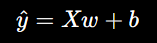

Example

Suppose

```text
w =
[
2,
5
]

b = 3
```

New sample

```text
Area = 4

Bedrooms = 2
```

Prediction

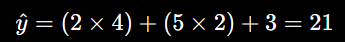

Nothing changes here.

The difference is **how the weights are learned**.

---

## Step 6 — Compute the Loss

Ordinary Linear Regression minimizes only

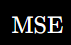

Elastic Net minimizes

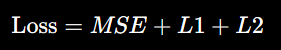

Conceptually,

```text
Prediction Error
        +
Penalty for Large Coefficients
        +
Penalty for Too Many Non-zero Coefficients
```

This prevents the model from making unnecessarily large or complex coefficients.

---

## Step 7 — Compute Gradients

The optimizer computes

> "How should each coefficient change to reduce the total loss?"

Notice:

The gradient now comes from

* Prediction error
* L1 penalty
* L2 penalty

instead of prediction error alone.

---

## Step 8 — Update Coefficients

The optimizer updates

```text
Old Weight
      ↓
Gradient
      ↓
New Weight
```

This repeats many times.

Example

Iteration 1

```text
w =
[
5.6,
3.1
]
```

Iteration 50

```text
w =
[
3.7,
2.0
]
```

Iteration 200

```text
w =
[
2.8,
1.3
]
```

Eventually

The loss stops decreasing.

Training ends.

---

## Step 9 — Final Model

Suppose training finishes with

```text
Area      2.7
Bedrooms  1.4
Garage    0
Age       0
```

Notice

Some features disappeared completely.

This is because of the L1 penalty.

---

# Training Process

Let's see what happens internally during training.

---

## Iteration 1

Initialize

```text
Weights

↓

Predict

↓

Calculate Error

↓

Calculate Penalty

↓

Total Loss

↓

Gradient

↓

Update Weights
```

---

## Iteration 2

Repeat the same steps

```text
Predict

↓

Loss

↓

Gradient

↓

Update
```

---

## ...

Hundreds or thousands of iterations later

```text
Weights stabilize
```

Training stops.

---

### What is changing every iteration?

Only

```text
Coefficients
```

The dataset never changes.

---

### What influences the updates?

Three things:

1.

Prediction error

2.

L1 penalty

3.

L2 penalty

Together they decide how each coefficient moves.

---

# Prediction Process

Prediction is surprisingly simple.

Once training is complete,

Elastic Net behaves exactly like Linear Regression.

---

## Step 1

Receive a new sample

Example

```text
Area = 1600

Bedrooms = 3
```

---

## Step 2

Scale using the **same scaler**

```python
new_house = scaler.transform([[1600, 3]])
```

Never call

```python
fit_transform()
```

on new data.

Only

```python
transform()
```

---

## Step 3

Multiply by learned coefficients

Suppose

```text
Area      2.6

Bedrooms  1.3

Intercept 5
```

Prediction

[
\hat y
======

2.6(\text{Area})
+
1.3(\text{Bedrooms})
+
5
]

---

## Step 4

Return prediction

Example

```text
Predicted Price

=
67.5 Lakhs
```

---

# Flow Diagram

```text
                Training Phase

          Dataset (X, y)
                 │
                 ▼
         Train-Test Split
                 │
                 ▼
        StandardScaler.fit()
                 │
                 ▼
      Initialize Weights (w, b)
                 │
                 ▼
        Predict Using Xw + b
                 │
                 ▼
      Compute MSE + L1 + L2 Loss
                 │
                 ▼
         Compute Gradients
                 │
                 ▼
        Update Weights
                 │
        Repeat Until Convergence
                 │
                 ▼
          Final Coefficients


----------------------------------------------


            Prediction Phase

          New Sample
               │
               ▼
      StandardScaler.transform()
               │
               ▼
         Xw + b
               │
               ▼
      Predicted Value
```

---

# Small Numerical Example

Suppose we want to predict house prices.

Dataset

| House | Area | Bedrooms | Price |
| ----- | ---: | -------: | ----: |
| 1     | 1000 |        2 |    40 |
| 2     | 1200 |        3 |    50 |
| 3     | 1500 |        3 |    60 |
| 4     | 1800 |        4 |    72 |

---

Initially

```text
Weights

Area = 0

Bedrooms = 0
```

Prediction

```text
0

0

0

0
```

Large error.

---

After several iterations

Weights become

```text
Area = 0.04

Bedrooms = 6
```

Predictions improve.

---

Suppose Garage was another feature.

Initially

```text
Garage = 4
```

After training

```text
Garage = 0
```

Elastic Net concludes

Garage adds little information.

It removes it.

---

Final model

```text
Price

=
0.04 × Area

+

6 × Bedrooms

+

Intercept
```

---

# Visualization of Working

Imagine only two coefficients:

```text
Area

Bedrooms
```

Initially

```text
Area      12

Bedrooms  15
```

↓

After first updates

```text
Area      9

Bedrooms 11
```

↓

Later

```text
Area      6

Bedrooms 7
```

↓

Final

```text
Area      4

Bedrooms 5
```

Large coefficients gradually shrink.

---

Now imagine another feature

```text
ZipCode
```

Initially

```text
ZipCode = 6
```

↓

Training

```text
ZipCode = 3
```

↓

Later

```text
ZipCode = 1
```

↓

Finally

```text
ZipCode = 0
```

The feature disappears completely.

This is the L1 component of Elastic Net in action.

---

Another way to visualize the training process:

```text
Large Coefficients
        │
        ▼
Penalty Applied
        │
        ▼
Shrink Weights
        │
        ▼
Some Reach Zero
        │
        ▼
Simpler Model
        │
        ▼
Better Generalization
```

---

# Algorithm Summary

### Input

* Feature matrix **X**
* Target values **y**

---

### Training

1. Split the dataset.
2. Scale the features.
3. Initialize coefficients.
4. Predict using (Xw + b).
5. Compute the total loss (MSE + L1 penalty + L2 penalty).
6. Compute gradients.
7. Update coefficients using an optimization algorithm.
8. Repeat until convergence.

---

### Prediction

1. Scale the new sample using the same scaler.
2. Compute (Xw + b).
3. Return the predicted value.

---

### Key Takeaways

* The **prediction equation** is the same as Linear Regression.
* The **training objective** is different because it includes **both L1 and L2 regularization**.
* **L2** shrinks coefficients toward zero.
* **L1** can make coefficients exactly zero, enabling feature selection.
* **`alpha`** controls the overall regularization strength.
* **`l1_ratio`** controls the balance between L1 and L2 penalties.
* The result is a model that is often more stable than Lasso while still performing feature selection.

---